# Comparison and Testing of BaselineGAT with Custom MPNN
## Loading and split dataset for BaselineGNNs

In [1]:
from atoMLtype.GNN.GNNmodel import GNNTrainer, BaselineGCN, BaselineGAT
from atoMLtype.GNN.GNNdataset import GNNdataset
from atoMLtype.utils.metrics import plot_atom_distribution, plot_full_heatmap, \
    plot_category_heatmap, plot_detailed_cross_category_heatmap
from torch.utils.data import random_split
import numpy as np

[12:10:47] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[12:10:47] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[12:10:47] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[12:10:47] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 152
num_y_ATs = 75
FULL DATASET:


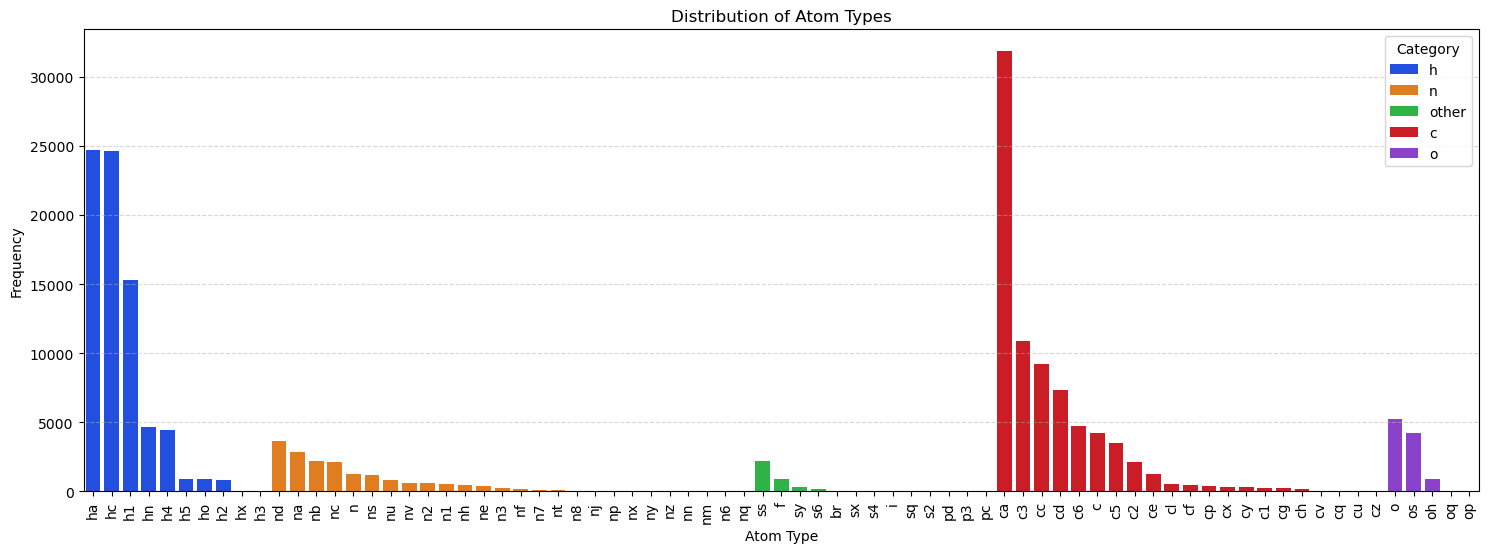

,Atom Type,Count,Category
0,ha,24728,h
1,hc,24621,h
2,h1,15297,h
3,hn,4701,h
4,h4,4442,h
...,...,...,...
70,o,5248,o
71,os,4222,o
72,oh,879,o
73,oq,12,o


In [2]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))

print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(gnn_test_dataset))
test_size = len(gnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(gnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(gnn_test_dataset.all_labels))

## Testing BaselineGCN - 2 layer conv nn on atom features only with relu activation functions

BaselineGCN - Number of parameters: 379467


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.7621 | Val Loss: 0.7589
Epoch - 20: Train Loss: 0.6756 | Val Loss: 0.6954
Epoch - 30: Train Loss: 0.6396 | Val Loss: 0.6556


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.6174 | Val Loss: 0.6215
Epoch - 20: Train Loss: 0.5999 | Val Loss: 0.6072
Epoch - 30: Train Loss: 0.5865 | Val Loss: 0.6030


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.5819 | Val Loss: 0.5774
Epoch - 20: Train Loss: 0.5713 | Val Loss: 0.5799
Epoch - 30: Train Loss: 0.5643 | Val Loss: 0.5777


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.5574 | Val Loss: 0.5706
Epoch - 20: Train Loss: 0.5503 | Val Loss: 0.5710
Epoch - 30: Train Loss: 0.5457 | Val Loss: 0.5776


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.5404 | Val Loss: 0.5815
Epoch - 20: Train Loss: 0.5364 | Val Loss: 0.5777
Epoch - 30: Train Loss: 0.5317 | Val Loss: 0.5801


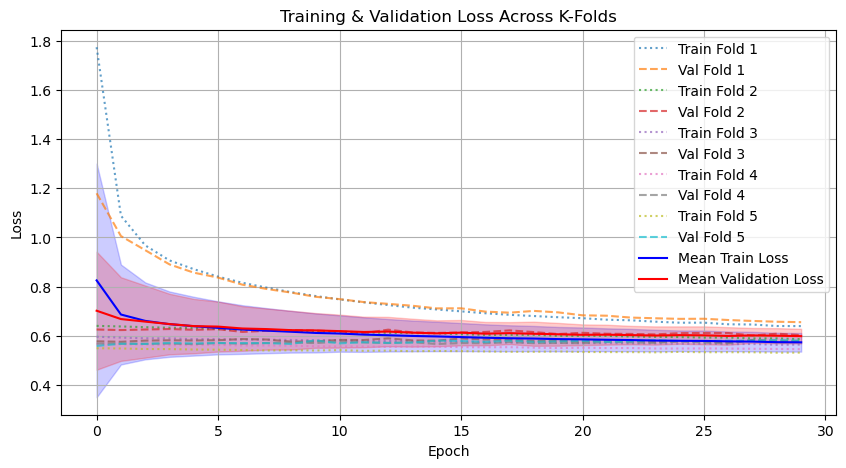

Evaluation Metrics: {'Accuracy': 0.7741011947365524, 'F1-score': 0.7534244196659878}


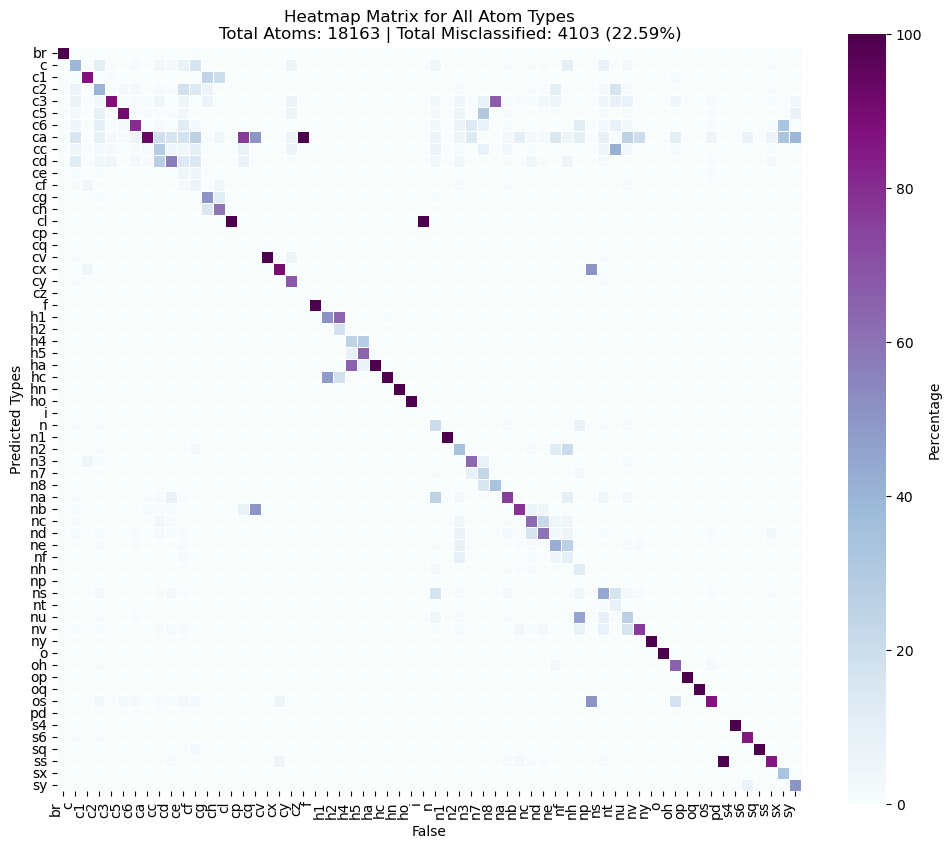

In [3]:
# Initialize BaselineGCN for classification
model = BaselineGCN(num_node_features=num_node_feat, num_atom_types=num_y_ATs, hidden_dim=512)
trainer = GNNTrainer(model, dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer.train()
metrics = trainer.evaluate_model(test_dataset)

y_true_labels, y_pred_labels = trainer.predict(test_dataset)

plot_full_heatmap(y_true=y_true_labels, y_pred=y_pred_labels)


# Loading MPNNdataset - Directed Bond Graphs for custom D-MPNN

In [133]:
from atoMLtype.GNN.GNNdataset import MPNNdataset

In [134]:
# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
mpnn_test_dataset = MPNNdataset(sdf_path, json_labels, collapse=True)

[16:39:38] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[16:39:38] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[16:39:38] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[16:39:39] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

FULL DATASET:


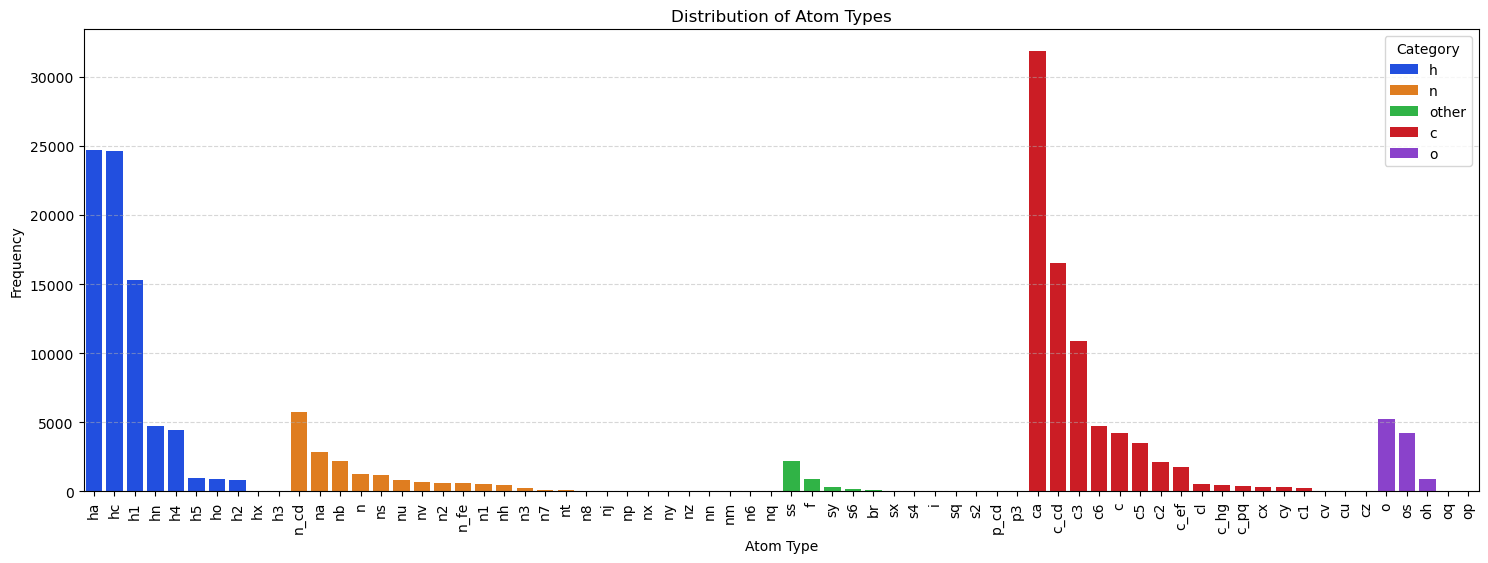

num_atom_features = 154
num_bond_features = 14
num_y_ATs = 68
Total dataset size: 6390
Train split size: 5751
Test split size: 639
First train sample: Data(x=[28, 154], edge_index=[2, 58], edge_attr=[58, 14], y=[28], y_values=[28], mol_name='ZINC06858245', atom_idx_in_mol=[28], global_atom_idx=[28])
First test sample: Data(x=[17, 154], edge_index=[2, 36], edge_attr=[36, 14], y=[17], y_values=[17], mol_name='ZINC20216425', atom_idx_in_mol=[17], global_atom_idx=[17])


In [135]:
# Initialize dataset
num_atom_feat = mpnn_test_dataset[0].x.shape[1]
num_bond_feat = mpnn_test_dataset[0].edge_attr.shape[1]
num_y_ATs = len(set(mpnn_test_dataset.all_labels))

# Split Train and test dataset (95% train, 5% test)
train_size = int(0.90 * len(mpnn_test_dataset))
test_size = len(mpnn_test_dataset) - train_size
train_dataset, test_dataset = random_split(mpnn_test_dataset, [train_size, test_size])

print("FULL DATASET:")
plot_atom_distribution(np.array(mpnn_test_dataset.all_labels))

print(f"num_atom_features = {num_atom_feat}")
print(f"num_bond_features = {num_bond_feat}")
print(f"num_y_ATs = {num_y_ATs}")

print("Total dataset size:", len(mpnn_test_dataset))
print("Train split size:", len(train_dataset))
print("Test split size:", len(test_dataset))

# Check first few samples from each to ensure they aren't empty
print("First train sample:", train_dataset[0])
print("First test sample:", test_dataset[0])

In [136]:
from atoMLtype.GNN.GNNmodel import Att_AtomBondMPNN

model_AtomMPNN = Att_AtomBondMPNN(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN  = GNNTrainer(model_AtomMPNN , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=10, random_seed=21)
trainer_AtomMPNN.train()
metrics_AtomMPNN  = trainer_AtomMPNN .evaluate_model(test_dataset)

y_true_AtomMPNN, y_pred_AtomMPNN  = trainer_AtomMPNN .predict(test_dataset)

plot_full_heatmap(y_true=y_true_AtomMPNN, y_pred=y_pred_AtomMPNN )

Att_AtomBondMPNN - Number of parameters: 10985550


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.0215 | Val Loss: 0.0207


KeyboardInterrupt: 

Att_AtomBondMPNN_analysis - Number of parameters: 10985550


---------KFOLD: 0----------
Epoch - 10: Train Loss: 0.0536 | Val Loss: 0.1121
Epoch - 20: Train Loss: 0.0174 | Val Loss: 0.0097
Epoch - 30: Train Loss: 0.0159 | Val Loss: 0.0127


---------KFOLD: 1----------
Epoch - 10: Train Loss: 0.0118 | Val Loss: 0.0144
Epoch - 20: Train Loss: 0.0300 | Val Loss: 0.0149
Epoch - 30: Train Loss: 0.0150 | Val Loss: 0.0163


---------KFOLD: 2----------
Epoch - 10: Train Loss: 0.0111 | Val Loss: 0.0276
Epoch - 20: Train Loss: 0.0048 | Val Loss: 0.0289
Epoch - 30: Train Loss: 0.0061 | Val Loss: 0.0320


---------KFOLD: 3----------
Epoch - 10: Train Loss: 0.0095 | Val Loss: 0.0018
Epoch - 20: Train Loss: 0.0085 | Val Loss: 0.0037
Epoch - 30: Train Loss: 0.0130 | Val Loss: 0.0092


---------KFOLD: 4----------
Epoch - 10: Train Loss: 0.0075 | Val Loss: 0.0226
Epoch - 20: Train Loss: 0.0044 | Val Loss: 0.0198
Epoch - 30: Train Loss: 0.0034 | Val Loss: 0.0283


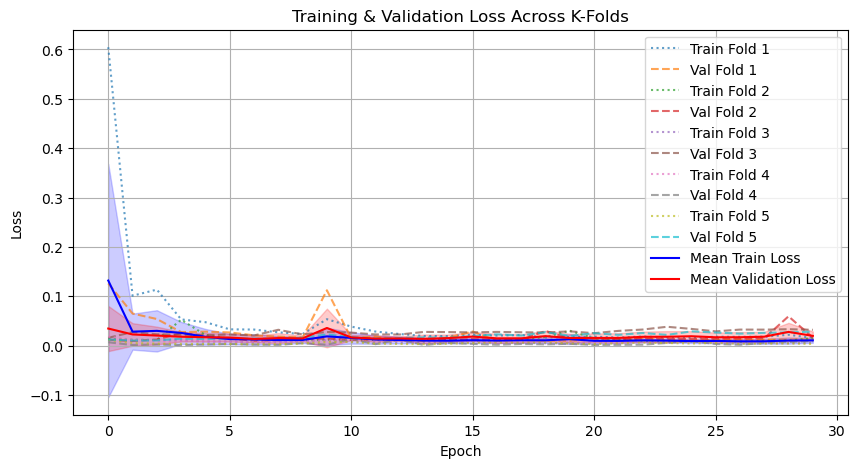

Evaluation Metrics: {'Accuracy': 0.9986032018910498, 'F1-score': 0.9985716155600592}


In [118]:
import importlib
import atoMLtype.GNN.GNNmodel
import atoMLtype.utils.predRecord
importlib.reload(atoMLtype.utils.predRecord)
importlib.reload(atoMLtype.GNN.GNNmodel)
from atoMLtype.GNN.GNNmodel import GNNTrainer
from atoMLtype.GNN.GNNmodel import Att_AtomBondMPNN_analysis

model_AtomMPNN_analylsis = Att_AtomBondMPNN_analysis(atom_input_dim=num_atom_feat, bond_input_dim=num_bond_feat, hidden_dim=512, \
                                       num_classes=num_y_ATs, num_layers=10)
trainer_AtomMPNN_ana  = GNNTrainer(model_AtomMPNN_analylsis , dataset=train_dataset, batch_size=32, learning_rate=0.001, \
                      epochs=30, k_folds=5, task="classification", random_seed=21)
trainer_AtomMPNN_ana.train()
metrics_AtomMPNN_ana  = trainer_AtomMPNN_ana.evaluate_model(test_dataset)


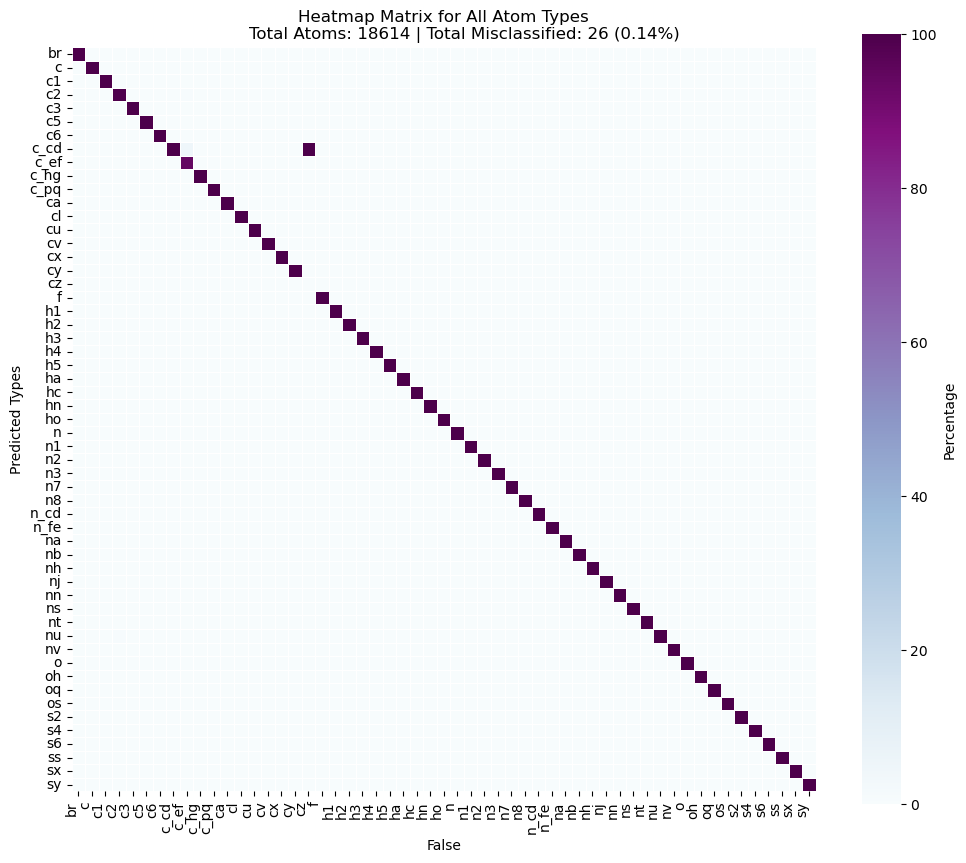

In [119]:
y_true_AtomMPNN_ana, y_pred_AtomMPNN_ana  = trainer_AtomMPNN_ana.predict(test_dataset)

plot_full_heatmap(y_true=y_true_AtomMPNN_ana, y_pred=y_pred_AtomMPNN_ana )

predRecord  = trainer_AtomMPNN_ana.predict_analysis(test_dataset)


In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import seaborn as sns

def visualize_embeddings(embeddings, labels, method='umap', label_type='True Label', max_points=5000):
    """
    Reduce and visualize atom embeddings with UMAP or t-SNE.

    Args:
        embeddings (np.ndarray): Shape [num_atoms, hidden_dim]
        labels (List[str or int]): Length [num_atoms]
        method (str): 'umap' or 'tsne'
        label_type (str): Label for legend (e.g. 'true_label' or 'pred_label')
        max_points (int): Subsample if too large
    """
    if len(embeddings) > max_points:
        embeddings = embeddings[:max_points]
        labels = labels[:max_points]

    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'.")

    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("husl", len(set(labels)))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette=palette, s=10, alpha=0.7)
    plt.title(f"{method.upper()} projection of atom embeddings")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend(title=label_type, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


/var/folders/q0/qj0r7jj952ngj7mn6px78_gw0000gn/T/ipykernel_4062/3971785210.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


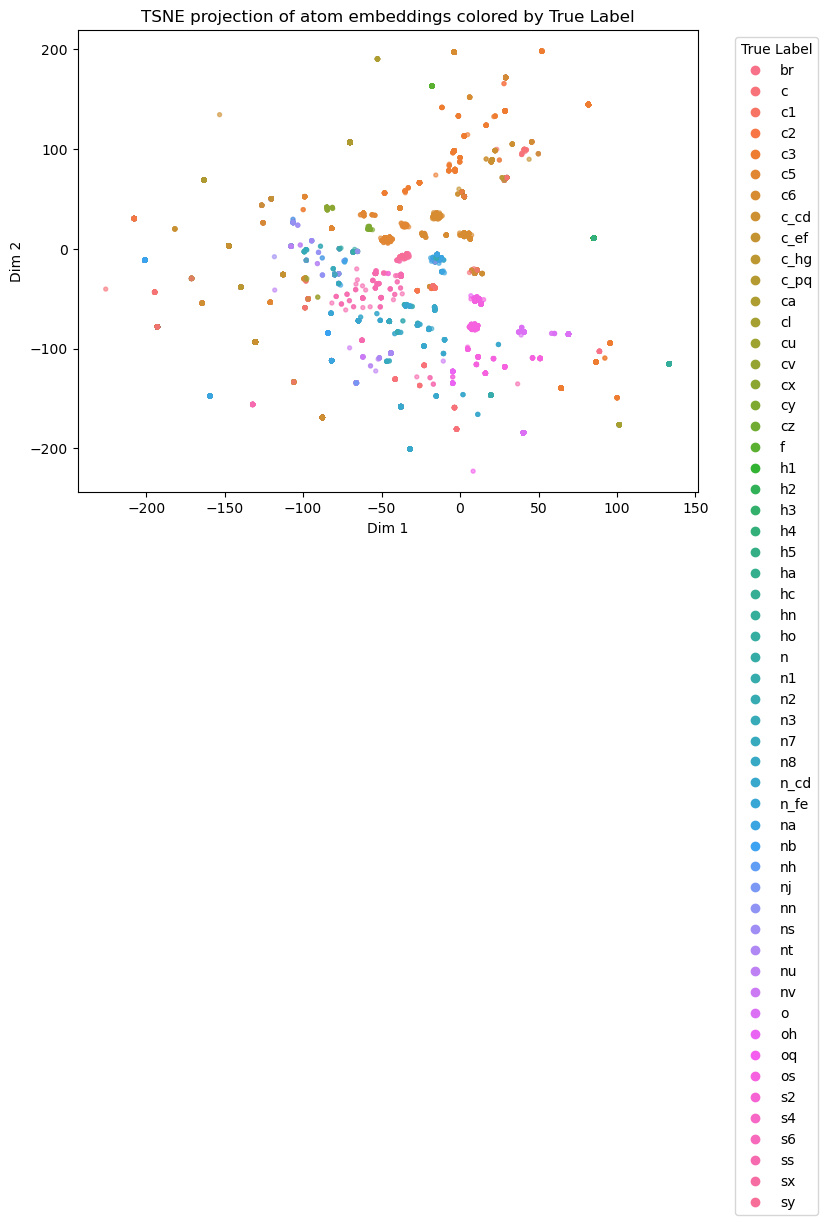

In [131]:
visualize_embeddings(
    predRecord.get_x_embedding(),
    predRecord.get_labels(label_type='true'),
    method='tsne',
    label_type='True Label',
    max_points=20000
)

/var/folders/q0/qj0r7jj952ngj7mn6px78_gw0000gn/T/ipykernel_4062/3971785210.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


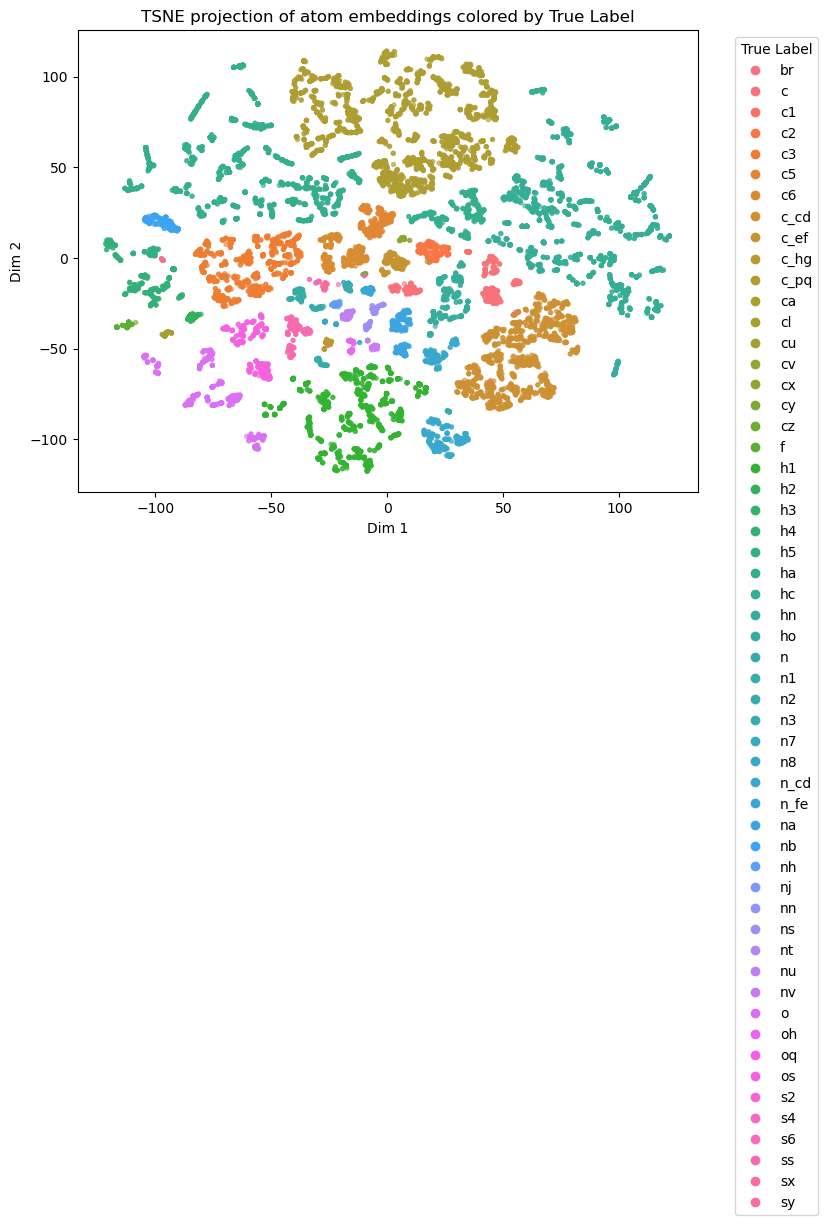

In [132]:
visualize_embeddings(
    predRecord.get_clf_embedding(),
    predRecord.get_labels(label_type='true'),
    method='tsne',
    label_type='True Label',
    max_points=20000
)

In [123]:
def visualize_embeddings(embeddings, labels, mismatches_mask=None, pred_labels=None,
                         method='umap', label_type='True Label', max_points=5000):
    """
    Reduce and visualize atom embeddings with optional mismatch overlay colored by predicted label.

    Args:
        embeddings (np.ndarray): [num_atoms, hidden_dim]
        labels (List[str]): True labels
        mismatches_mask (List[bool]): Optional mask of misclassified atoms
        pred_labels (List[str]): Optional predicted labels (used for mismatches)
        method (str): 'umap' or 'tsne'
        label_type (str): Label for legend title
        max_points (int): Limit number of plotted points
    """
    if len(embeddings) > max_points:
        embeddings = embeddings[:max_points]
        labels = labels[:max_points]
        if mismatches_mask is not None:
            mismatches_mask = mismatches_mask[:max_points]
        if pred_labels is not None:
            pred_labels = pred_labels[:max_points]

    # Build label-to-color mapping using sorted true labels
    unique_labels = sorted(set(labels))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    numeric_labels = [label_to_index[l] for l in labels]

    # Dimension reduction
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    else:
        raise ValueError("Method must be 'umap' or 'tsne'.")

    reduced = reducer.fit_transform(embeddings)

    # Plot base layer (all atoms, true label color)
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette("husl", len(unique_labels))
    colors = [palette[label_to_index[l]] for l in labels]
    plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, s=8, alpha=0.6)

    # Overlay mismatches with pred label color + "X"
    if mismatches_mask is not None and pred_labels is not None:
        mismatches = np.array(mismatches_mask)
        mismatch_coords = reduced[mismatches]
        mismatch_colors = [palette[label_to_index[pred_labels[i]]] for i in range(len(labels)) if mismatches[i]]

        plt.scatter(mismatch_coords[:, 0], mismatch_coords[:, 1], c=mismatch_colors,
                    marker='x', s=40, linewidths=1.5, edgecolors='red', label='Mismatches')

    # Create sorted legend
    handles = [
        plt.Line2D([], [], marker='o', linestyle='', color=palette[i], label=label)
        for label, i in label_to_index.items()
    ]
    if mismatches_mask is not None:
        handles.append(plt.Line2D([], [], marker='x', linestyle='', color='gray', label='Mismatches'))

    plt.legend(handles=handles, title=label_type, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"{method.upper()} projection of atom embeddings colored by {label_type}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.tight_layout()
    plt.show()


/var/folders/q0/qj0r7jj952ngj7mn6px78_gw0000gn/T/ipykernel_4062/3971785210.py:50: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(mismatch_coords[:, 0], mismatch_coords[:, 1], c=mismatch_colors,
/var/folders/q0/qj0r7jj952ngj7mn6px78_gw0000gn/T/ipykernel_4062/3971785210.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


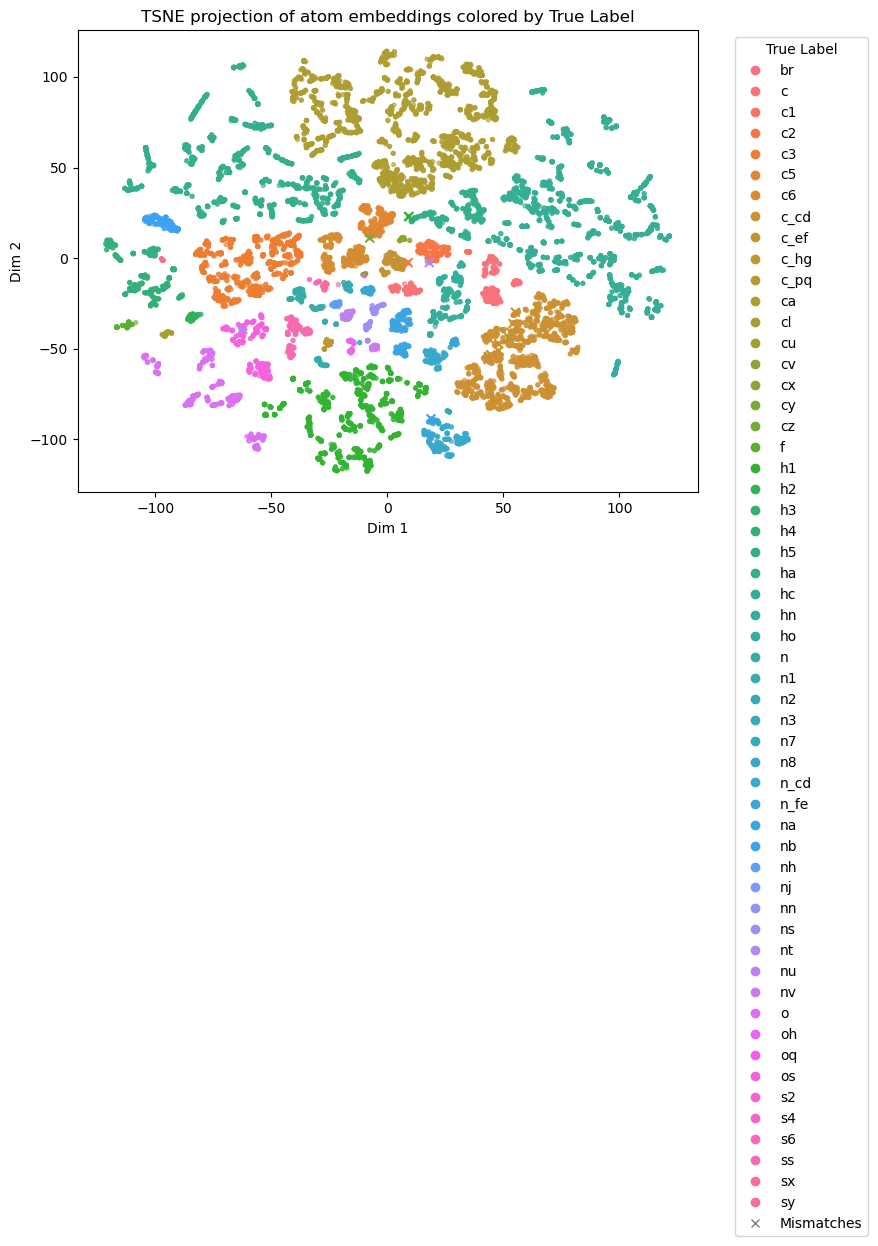

In [124]:
embeddings = predRecord.get_clf_embedding()
true_labels = predRecord.get_labels('true')
pred_labels = predRecord.get_labels('pred')
mismatches_mask = [t != p for t, p in zip(true_labels, pred_labels)]

visualize_embeddings(
    embeddings,
    labels=true_labels,
    mismatches_mask=mismatches_mask,
    pred_labels=pred_labels,
    method='tsne',
    label_type='True Label',
    max_points=20000
)


In [125]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
from typing import List
from atoMLtype.utils.predRecord import AtomPrediction
def draw_molecule_with_mismatches(mol: Chem.Mol, atom_predictions: List[AtomPrediction], image_size=(400, 300)):
    """
    Draws a molecule highlighting mismatched atoms in red.

    Args:
        mol (Chem.Mol): RDKit molecule
        atom_predictions (List[AtomPrediction]): List of AtomPrediction for this molecule
        image_size (tuple): Output image size (width, height)
    
    Returns:
        PIL.Image: Rendered molecule image
    """
    highlight_atoms = []
    atom_colors = {}

    for ap in atom_predictions:
        if ap.true_label != ap.pred_label:
            highlight_atoms.append(ap.atom_idx_in_mol)
            atom_colors[ap.atom_idx_in_mol] = (1.0, 0.0, 0.0)  # red for mismatches

    drawer = rdMolDraw2D.MolDraw2DCairo(image_size[0], image_size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=atom_colors
    )
    drawer.FinishDrawing()
    png_data = drawer.GetDrawingText()

    return Image.open(io.BytesIO(png_data))


ZINC18155362 atom 0, pred AT c_cd for ca
ZINC18155362 atom 1, pred AT c_cd for ca
ZINC18155362 atom 2, pred AT c_cd for ca
ZINC18155362 atom 4, pred AT c_cd for ca
ZINC18155362 atom 5, pred AT c_cd for ca


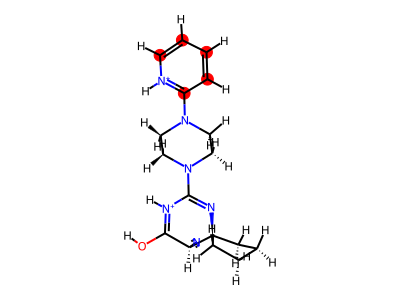

ZINC06484956 atom 11, pred AT nu for c2
ZINC06484956 atom 15, pred AT nu for os
ZINC06484956 atom 31, pred AT h1 for ha
ZINC06484956 atom 32, pred AT h1 for ha


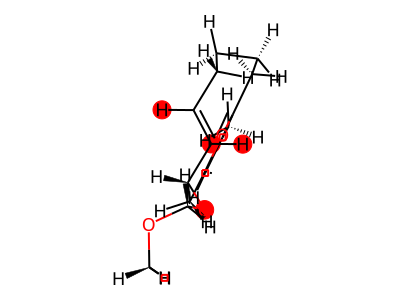

ZINC00339622 atom 9, pred AT c2 for c_ef


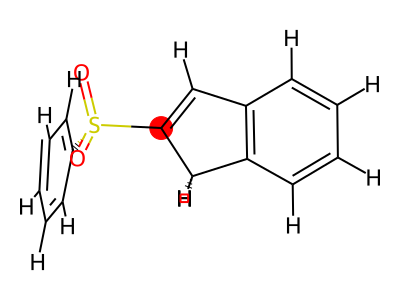

ZINC15226782 atom 7, pred AT c_cd for cz


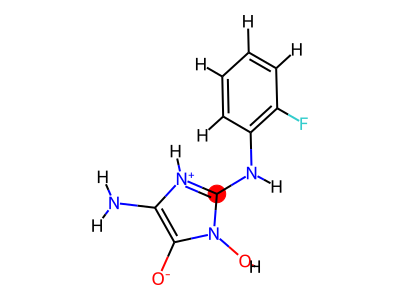

ZINC05489878 atom 16, pred AT cy for c5


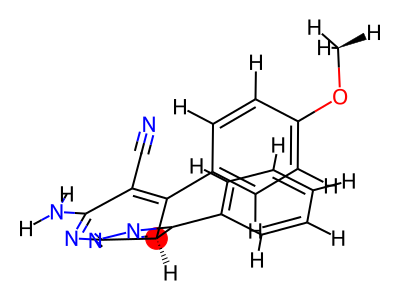

ZINC01578465 atom 9, pred AT c_cd for ca


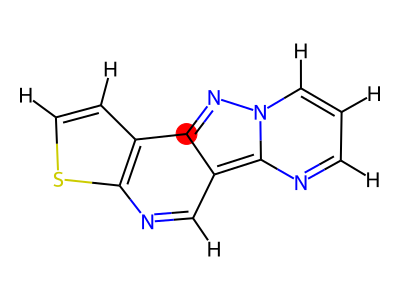

ZINC03847121 atom 0, pred AT c_cd for c_ef
ZINC03847121 atom 1, pred AT c_cd for c_ef
ZINC03847121 atom 2, pred AT c_cd for c_ef
ZINC03847121 atom 3, pred AT c_cd for c_ef
ZINC03847121 atom 4, pred AT c_cd for c_ef
ZINC03847121 atom 5, pred AT c_cd for c_ef
ZINC03847121 atom 8, pred AT c_cd for c_ef
ZINC03847121 atom 9, pred AT c_cd for c_ef
ZINC03847121 atom 10, pred AT c_cd for c_ef
ZINC03847121 atom 11, pred AT c_cd for c_ef


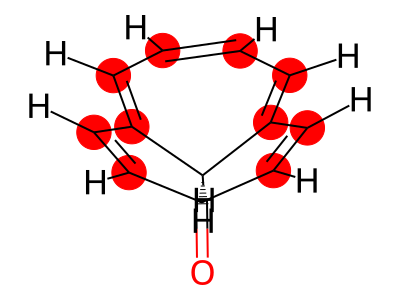

ZINC05499548 atom 6, pred AT ca for c_cd


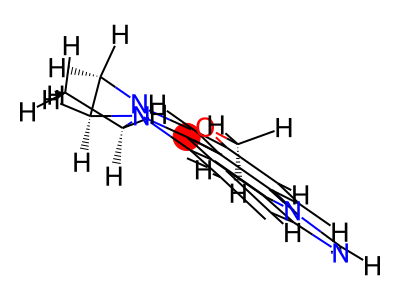

ZINC15779092 atom 3, pred AT nb for n_cd


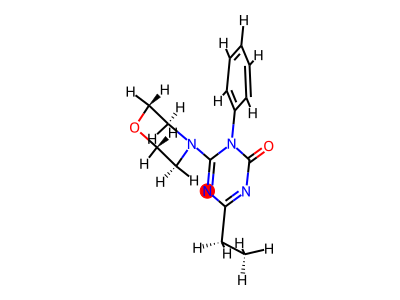

ZINC12941617 atom 20, pred AT c_cd for c


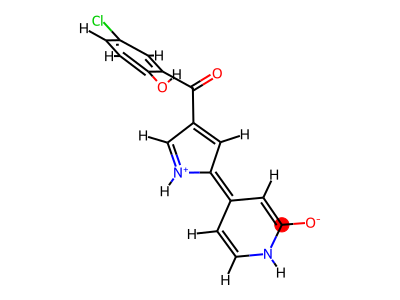

In [130]:
import random

mismatched_mols = predRecord.get_mismatched_molecules()
original_dataset = getattr(test_dataset, 'dataset', test_dataset)

for mol_name, atom_preds in mismatched_mols.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol_idx = original_dataset.mol_names.index(mol_name)
    mol = original_dataset.sdf_dataset.X_molecules[mol_name]

    img = draw_molecule_with_mismatches(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")
